<a href="https://colab.research.google.com/github/Alberto2804/ProyectoIA_Salud/blob/main/datos_ictus.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
!pip install shap

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier

df = pd.read_csv('datos_ictus.csv')

df = df.drop('id', axis=1)

df['bmi'] = df['bmi'].fillna(df['bmi'].mean())

df_numerico = pd.get_dummies(df, drop_first=True)

X = df_numerico.drop('stroke', axis=1)
y = df_numerico['stroke']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


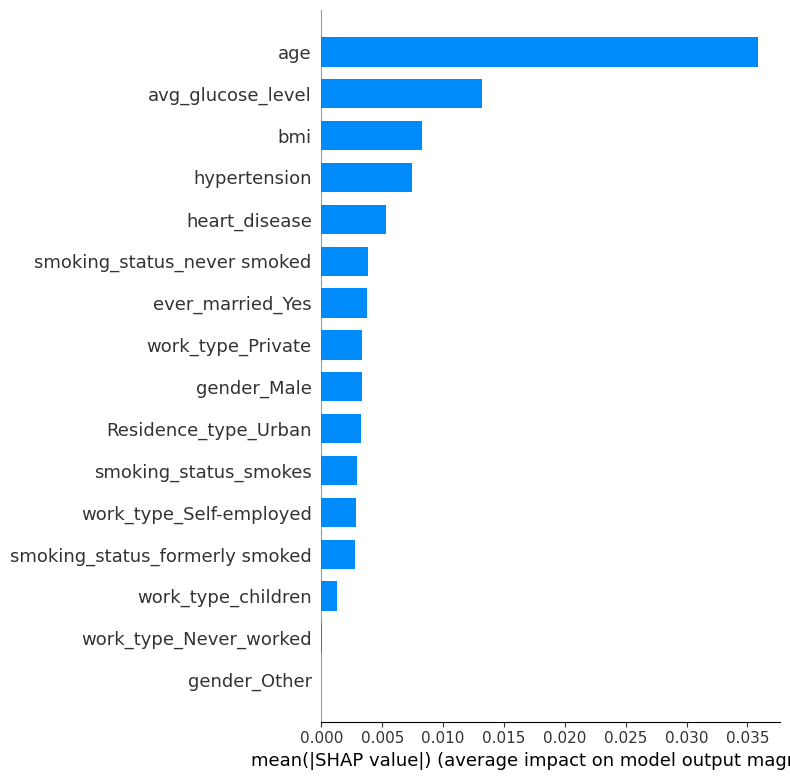

In [6]:
import shap
import matplotlib.pyplot as plt


modelo = RandomForestClassifier(random_state=42)
modelo.fit(X_train, y_train)

explainer = shap.TreeExplainer(modelo)
shap_values = explainer.shap_values(X_test)


shap.summary_plot(shap_values[:, :, 1], X_test, plot_type="bar")